In [76]:

import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [77]:
df = pd.read_csv(r"D:\Documents\Python Projects\python-for-ai\heart_disease_prediction\heart.csv")

In [78]:
df.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [79]:
categorical_col =[col for col in df.columns if df[col].dtype=="str"]
categorical_col

['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

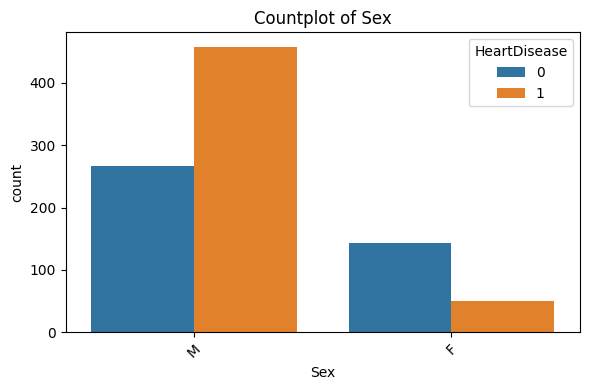

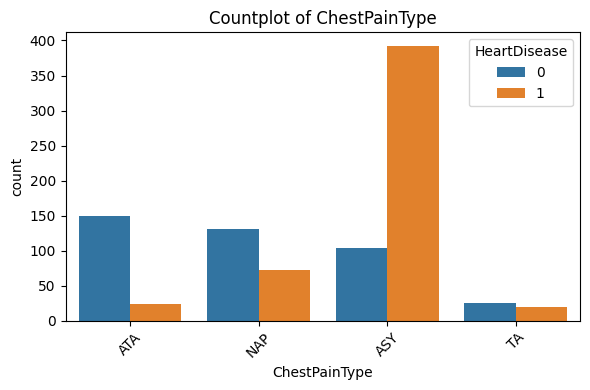

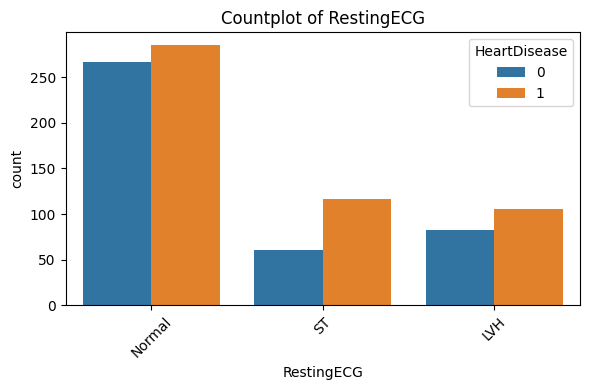

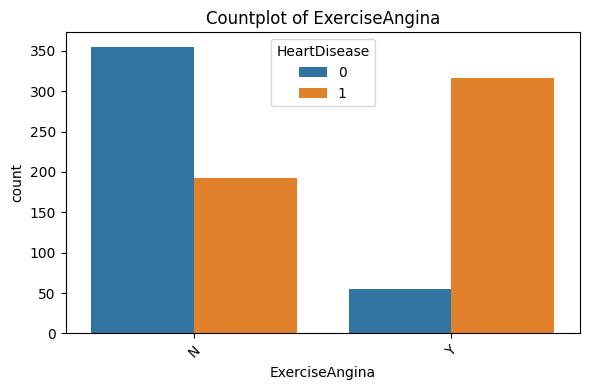

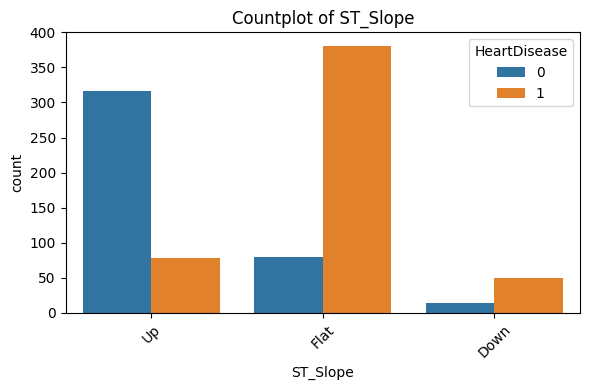

In [80]:
for col in categorical_col:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue="HeartDisease")
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    

In [81]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [82]:
df_encoded = pd.get_dummies(df,drop_first=True).astype(int)

In [83]:
df_encoded

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [100]:
X = df_encoded.drop("HeartDisease", axis=1)
y = df_encoded["HeartDisease"]

In [85]:
numeric_col = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']

In [86]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X[numeric_col]= scaler.fit_transform(X[numeric_col])

In [98]:
y.shape

(918,)

In [94]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [101]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.33, random_state=42)

In [102]:
models = {
    "Logistic Regression" : LogisticRegression(),
    "Gaussian NB":GaussianNB(),
    "Decision Tree Classsifier":DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVC":SVC()
}


In [125]:
result = []

In [126]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc_score = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    result.append({
        'Model': name,
        'Accuracy': acc_score,
        'f1': f1
    })

In [127]:
result

[{'Model': 'Logistic Regression',
  'Accuracy': 0.8646864686468647,
  'f1': 0.881159420289855},
 {'Model': 'Gaussian NB',
  'Accuracy': 0.8646864686468647,
  'f1': 0.880466472303207},
 {'Model': 'Decision Tree Classsifier',
  'Accuracy': 0.7656765676567657,
  'f1': 0.7917888563049853},
 {'Model': 'KNN', 'Accuracy': 0.7062706270627063, 'f1': 0.7520891364902507},
 {'Model': 'SVC', 'Accuracy': 0.7227722772277227, 'f1': 0.7543859649122807}]

In [128]:
df_results = pd.DataFrame(result)

In [129]:
df_results

,Model,Accuracy,f1
0,Logistic Regression,0.864686,0.881159
1,Gaussian NB,0.864686,0.880466
2,Decision Tree Classsifier,0.765677,0.791789
3,KNN,0.706271,0.752089
4,SVC,0.722772,0.754386


In [132]:
import joblib
joblib.dump(models["Logistic Regression"],"Logistic.pkl")
joblib.dump(scaler,"scaler.pkl")
joblib.dump(X.columns.to_list(),"columns.pkl")

['columns.pkl']